# Heart Disease Prediction

Cardiovascular diseases are one of the leading causes of death worldwide.
Early detection of heart disease can significantly reduce mortality rates.

### Objectives
- Perform exploratory data analysis on patient health data
- Build machine learning models to predict heart disease
- Compare multiple models and select the best one
- Provide actionable recommendations to hospitals

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

import warnings
warnings.filterwarnings("ignore")

In [4]:
labels_df = pd.read_csv(r"C:\Users\NILESH\Downloads\labels.csv")
values_df = pd.read_csv(r"C:\Users\NILESH\Downloads\values.csv")

In [5]:
labels_df.head()

,patient_id,heart_disease_present
0,0z64un,0
1,ryoo3j,0
2,yt1s1x,1
3,l2xjde,1
4,oyt4ek,0


In [6]:
values_df.head()

,patient_id,slope_of_peak_exercise_st_segment,thal,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina
0,0z64un,1,normal,128,2,0,0,2,308,0.0,1,45,170,0
1,ryoo3j,2,normal,110,3,0,0,0,214,1.6,0,54,158,0
2,yt1s1x,1,normal,125,4,3,0,2,304,0.0,1,77,162,1
3,l2xjde,1,reversible_defect,152,4,0,0,0,223,0.0,1,40,181,0
4,oyt4ek,3,reversible_defect,178,1,0,0,2,270,4.2,1,59,145,0


In [7]:
df = pd.merge(values_df, labels_df, on="patient_id", how="inner")
df.head()

,patient_id,slope_of_peak_exercise_st_segment,thal,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina,heart_disease_present
0,0z64un,1,normal,128,2,0,0,2,308,0.0,1,45,170,0,0
1,ryoo3j,2,normal,110,3,0,0,0,214,1.6,0,54,158,0,0
2,yt1s1x,1,normal,125,4,3,0,2,304,0.0,1,77,162,1,1
3,l2xjde,1,reversible_defect,152,4,0,0,0,223,0.0,1,40,181,0,1
4,oyt4ek,3,reversible_defect,178,1,0,0,2,270,4.2,1,59,145,0,0


In [8]:
df.shape

(180, 15)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 15 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   patient_id                            180 non-null    object 
 1   slope_of_peak_exercise_st_segment     180 non-null    int64  
 2   thal                                  180 non-null    object 
 3   resting_blood_pressure                180 non-null    int64  
 4   chest_pain_type                       180 non-null    int64  
 5   num_major_vessels                     180 non-null    int64  
 6   fasting_blood_sugar_gt_120_mg_per_dl  180 non-null    int64  
 7   resting_ekg_results                   180 non-null    int64  
 8   serum_cholesterol_mg_per_dl           180 non-null    int64  
 9   oldpeak_eq_st_depression              180 non-null    float64
 10  sex                                   180 non-null    int64  
 11  age                

In [10]:
df.describe()

,slope_of_peak_exercise_st_segment,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina,heart_disease_present
count,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000
mean,1.550000,131.311111,3.155556,0.694444,0.161111,1.050000,249.211111,1.010000,0.688889,54.811111,149.483333,0.316667,0.444444
std,0.618838,17.010443,0.938454,0.969347,0.368659,0.998742,52.717969,1.121357,0.464239,9.334737,22.063513,0.466474,0.498290
min,1.000000,94.000000,1.000000,0.000000,0.000000,0.000000,126.000000,0.000000,0.000000,29.000000,96.000000,0.000000,0.000000
25%,1.000000,120.000000,3.000000,0.000000,0.000000,0.000000,213.750000,0.000000,0.000000,48.000000,132.000000,0.000000,0.000000
50%,1.000000,130.000000,3.000000,0.000000,0.000000,2.000000,245.500000,0.800000,1.000000,55.000000,152.000000,0.000000,0.000000
75%,2.000000,140.000000,4.000000,1.000000,0.000000,2.000000,281.250000,1.600000,1.000000,62.000000,166.250000,1.000000,1.000000
max,3.000000,180.000000,4.000000,3.000000,1.000000,2.000000,564.000000,6.200000,1.000000,77.000000,202.000000,1.000000,1.000000


## Exploratory Data Analysis

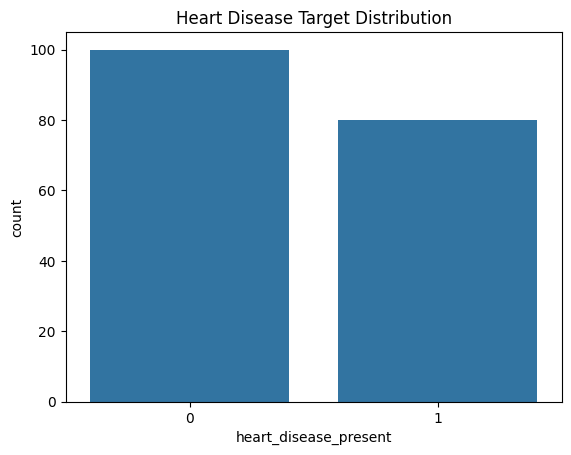

In [11]:
# Target Distribution

sns.countplot(x="heart_disease_present", data=df)
plt.title("Heart Disease Target Distribution")
plt.show()

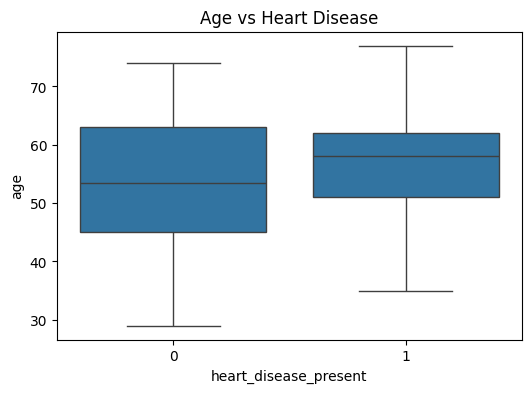

In [12]:
# Age vs Heart Disease

plt.figure(figsize=(6,4))
sns.boxplot(x="heart_disease_present", y="age", data=df)
plt.title("Age vs Heart Disease")
plt.show()

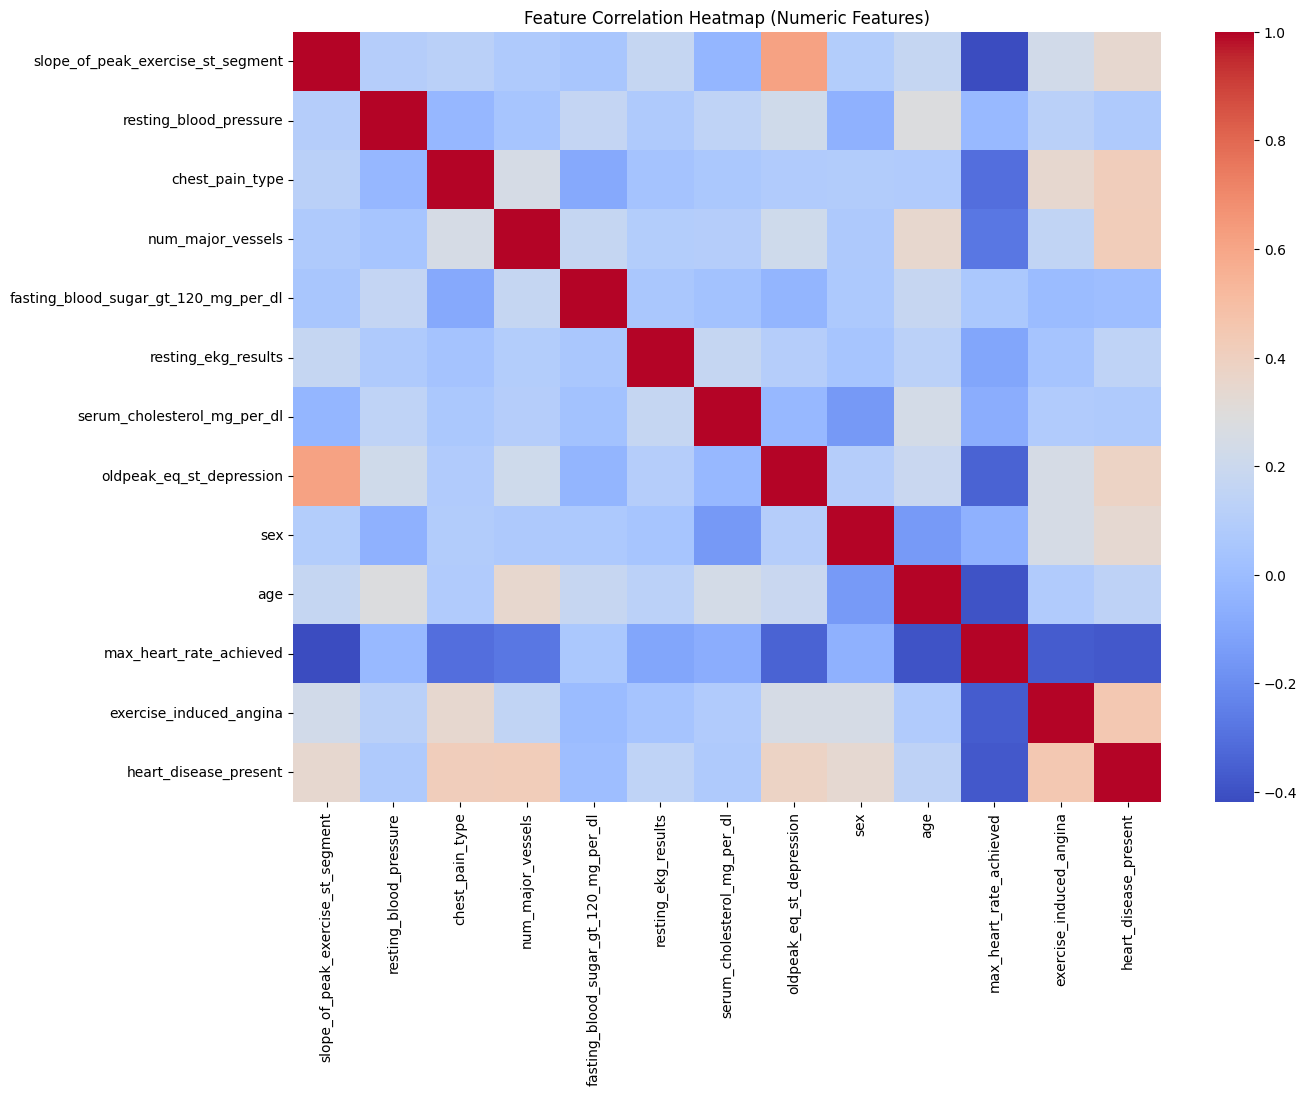

In [14]:
# Correlation Heatmap

numeric_df = df.select_dtypes(include=["int64", "float64"])

plt.figure(figsize=(14,10))
sns.heatmap(numeric_df.corr(), cmap="coolwarm", annot=False)
plt.title("Feature Correlation Heatmap (Numeric Features)")
plt.show()

## Data Preprocessing

In [15]:
# Drop Identifier Column

df.drop("patient_id", axis=1, inplace=True)

In [16]:
df

,slope_of_peak_exercise_st_segment,thal,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina,heart_disease_present
0,1,normal,128,2,0,0,2,308,0.0,1,45,170,0,0
1,2,normal,110,3,0,0,0,214,1.6,0,54,158,0,0
2,1,normal,125,4,3,0,2,304,0.0,1,77,162,1,1
3,1,reversible_defect,152,4,0,0,0,223,0.0,1,40,181,0,1
4,3,reversible_defect,178,1,0,0,2,270,4.2,1,59,145,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
175,2,reversible_defect,125,4,2,1,0,254,0.2,1,67,163,0,1
176,2,normal,180,4,0,0,1,327,3.4,0,55,117,1,1
177,2,reversible_defect,125,3,0,0,0,309,1.8,1,64,131,1,1
178,1,normal,124,3,2,1,0,255,0.0,1,48,175,0,0


In [17]:
# Encode Categorical Column

df = pd.get_dummies(df, columns=["thal"], drop_first=True)

In [18]:
df

,slope_of_peak_exercise_st_segment,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina,heart_disease_present,thal_normal,thal_reversible_defect
0,1,128,2,0,0,2,308,0.0,1,45,170,0,0,True,False
1,2,110,3,0,0,0,214,1.6,0,54,158,0,0,True,False
2,1,125,4,3,0,2,304,0.0,1,77,162,1,1,True,False
3,1,152,4,0,0,0,223,0.0,1,40,181,0,1,False,True
4,3,178,1,0,0,2,270,4.2,1,59,145,0,0,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
175,2,125,4,2,1,0,254,0.2,1,67,163,0,1,False,True
176,2,180,4,0,0,1,327,3.4,0,55,117,1,1,True,False
177,2,125,3,0,0,0,309,1.8,1,64,131,1,1,False,True
178,1,124,3,2,1,0,255,0.0,1,48,175,0,0,True,False


In [19]:
# Feature Target Split

X = df.drop("heart_disease_present", axis=1)
y = df["heart_disease_present"]

In [20]:
# Train Test Split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [21]:
# Feature Scaling

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

In [22]:
X_train

array([[-0.83939296, -0.02468392, -1.2808703 , ..., -0.68511879,
         0.8819171 , -0.79772404],
       [-0.83939296, -0.14940269, -1.2808703 , ..., -0.68511879,
         0.8819171 , -0.79772404],
       [ 0.79402037, -1.27187163, -2.3919867 , ...,  1.4596009 ,
         0.8819171 , -0.79772404],
       ...,
       [ 0.79402037, -0.64827777, -1.2808703 , ..., -0.68511879,
        -1.13389342,  1.25356634],
       [-0.83939296, -1.14715286,  0.94136251, ..., -0.68511879,
         0.8819171 , -0.79772404],
       [ 0.79402037, -0.9600747 , -0.16975389, ..., -0.68511879,
        -1.13389342,  1.25356634]], shape=(144, 14))

In [23]:
X_test

array([[-0.83939296,  1.59666009, -1.2808703 , -0.72932496, -0.49130368,
         0.97259753, -0.0572693 , -0.8927209 ,  0.66332496,  1.57284171,
        -0.31943154, -0.68511879,  0.8819171 , -0.79772404],
       [-0.83939296,  0.59890993,  0.94136251, -0.72932496, -0.49130368,
        -1.02817453,  0.94571733,  0.59557791,  0.66332496, -0.38498127,
         1.04820399,  1.4596009 , -1.13389342,  1.25356634],
       [ 0.79402037, -0.64827777,  0.94136251,  0.32090298, -0.49130368,
        -1.02817453, -1.1159774 ,  0.40954056,  0.66332496, -0.07585133,
        -1.68706707, -0.68511879, -1.13389342,  1.25356634],
       [-0.83939296, -0.02468392, -1.2808703 , -0.72932496, -0.49130368,
        -1.02817453,  0.33278106, -0.33460885,  0.66332496, -0.5910679 ,
         0.95702829, -0.68511879,  0.8819171 , -0.79772404],
       [-0.83939296, -0.523559  ,  0.94136251, -0.72932496, -0.49130368,
         0.97259753, -0.48446731, -0.8927209 ,  0.66332496, -0.69411122,
         1.64084606, -0.68

## Model Building

In [24]:
# Evaluation Function

def evaluate_model(model, X, y):
    preds = model.predict(X)
    return {
        "Accuracy": accuracy_score(y, preds),
        "Precision": precision_score(y, preds),
        "Recall": recall_score(y, preds),
        "F1 Score": f1_score(y, preds),
        "ROC AUC": roc_auc_score(y, preds)
    }

In [25]:
# Logistic Regression

lr = LogisticRegression()
lr.fit(X_train, y_train)

lr_result = evaluate_model(lr, X_test, y_test)
lr_result

{'Accuracy': 0.8333333333333334,
 'Precision': 0.7777777777777778,
 'Recall': 0.875,
 'F1 Score': 0.8235294117647058,
 'ROC AUC': 0.8375}

In [26]:
# K Nearest Neighbors

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

knn_result = evaluate_model(knn, X_test, y_test)
knn_result

{'Accuracy': 0.8333333333333334,
 'Precision': 0.7777777777777778,
 'Recall': 0.875,
 'F1 Score': 0.8235294117647058,
 'ROC AUC': 0.8375}

In [27]:
# Decision Tree

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

dt_result = evaluate_model(dt, X_test, y_test)
dt_result

{'Accuracy': 0.7777777777777778,
 'Precision': 0.75,
 'Recall': 0.75,
 'F1 Score': 0.75,
 'ROC AUC': 0.7750000000000001}

In [28]:
# Random Forest

rf = RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42)

rf.fit(X_train, y_train)
rf_result = evaluate_model(rf, X_test, y_test)
rf_result

{'Accuracy': 0.8611111111111112,
 'Precision': 0.7894736842105263,
 'Recall': 0.9375,
 'F1 Score': 0.8571428571428571,
 'ROC AUC': 0.86875}

In [29]:
# Support Vector Machine

svm = SVC(probability=True)
svm.fit(X_train, y_train)

svm_result = evaluate_model(svm, X_test, y_test)
svm_result

{'Accuracy': 0.8611111111111112,
 'Precision': 0.8235294117647058,
 'Recall': 0.875,
 'F1 Score': 0.8484848484848485,
 'ROC AUC': 0.8625}

## Model Comparison

In [30]:
model_comparison = pd.DataFrame({
    "Logistic Regression": lr_result,
    "KNN": knn_result,
    "Decision Tree": dt_result,
    "Random Forest": rf_result,
    "SVM": svm_result
}).T

model_comparison

,Accuracy,Precision,Recall,F1 Score,ROC AUC
Logistic Regression,0.833333,0.777778,0.8750,0.823529,0.83750
KNN,0.833333,0.777778,0.8750,0.823529,0.83750
Decision Tree,0.777778,0.750000,0.7500,0.750000,0.77500
Random Forest,0.861111,0.789474,0.9375,0.857143,0.86875
SVM,0.861111,0.823529,0.8750,0.848485,0.86250


## Best Model Selection

### Selected Model: Random Forest Classifier

Reasons:
- Best balance of Precision, Recall, and F1 Score
- Robust to non linear relationships
- Reduced overfitting through ensemble learning
- Feature importance helps clinical interpretability

## Feature Importance

In [32]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_}).sort_values(by="Importance", ascending=False)

feature_importance

,Feature,Importance
2,chest_pain_type,0.111035
10,max_heart_rate_achieved,0.109032
13,thal_reversible_defect,0.100694
9,age,0.098676
12,thal_normal,0.097300
7,oldpeak_eq_st_depression,0.094190
6,serum_cholesterol_mg_per_dl,0.090738
1,resting_blood_pressure,0.068975
3,num_major_vessels,0.064707
11,exercise_induced_angina,0.053921


## Hospital Recommendations

* Deploy model during routine health screenings
* Closely monitor ST depression and chest pain
* Early cardiac stress tests for high risk patients
* Integrate predictions with EMR systems
* Promote preventive lifestyle programs

## Challenges Faced

- Separate label and feature files required merging
- Categorical variable encoding without ordinal bias
- Risk of overfitting handled using Random Forest
- Scaling required for distance based models

## Conclusion

- This project demonstrates how machine learning can assist
in early detection of heart disease.

- Random Forest emerged as the best performing model and
is suitable for real world healthcare deployment.